# SurvSurf-v2 one-layer, one-neuron level curves

This notebook demonstrates level-curve behavior using the actual package output

```python
SurvSurf2DTaddTG.surface_as_prob_0_at_t0(ts, gs, xs)
```

with `hidden_dim=1` and `n_layers=0`, so the internal `MonotonicNetTaddTG` has exactly one layer and one output neuron.

For this one-layer implementation, the internal layer activation is the identity. After fixing `z0`, the offset terms cancel in the `t=0` subtraction and the raw zeroed surface is

$$
R(t,g)=\alpha t+\gamma\left[\sigma(m_t t+c_t)-\sigma(c_t)\right]\sigma(-m_g g+c_g).
$$

The public method then returns

$$
M(t,g,x)=\tanh(R(t,g)).
$$

At a plotted probability height $y$ from `surface_as_prob_0_at_t0`, the corresponding raw height is

$$
C_y=\operatorname{arctanh}(y).
$$

The level curve is obtained by solving

$$
\sigma(-m_g g+c_g)=\frac{C_y-\alpha t}{\gamma\left[\sigma(m_t t+c_t)-\sigma(c_t)\right]},
$$

so

$$
q_y(t)=g=\frac{c_g-\mathrm{logit}\left(\frac{C_y-\alpha t}{\gamma[\sigma(m_t t+c_t)-\sigma(c_t)]}\right)}{m_g}.
$$

The right-hand side is defined where $0 < (C_y-\alpha t)/(\gamma[\sigma(m_t t+c_t)-\sigma(c_t)]) < 1$. The division uses the grade coefficient $m_g$ because the solved sigmoid argument is $-m_g g+c_g$.

In [1]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

repo_root = Path.cwd()
if repo_root.name == "level_curves":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from monotonic_nn_surv_surf.core.survsurf_2d_sigm import SurvSurf2DTaddTG

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Helper functions

The functions below set the parameters of the actual one-neuron `SurvSurf2DTaddTG` model, evaluate `surface_as_prob_0_at_t0`, and compute the matching analytic level curve. Invalid parts of a level curve are returned as `NaN`, because those heights cannot be reached for that value of `t` in the displayed domain.

In [2]:
def sigmoid(u):
    return 1.0 / (1.0 + np.exp(-u))


def logit(p):
    return np.log(p / (1.0 - p))


def prob_to_raw_height(y):
    return np.arctanh(np.clip(y, -1 + 1e-12, 1 - 1e-12))


def delta_time(t, m_time, c_time):
    return sigmoid(m_time * t + c_time) - sigmoid(c_time)


def build_one_neuron_survsurf(*, alpha, gamma, m_time, c_time, m_grade, c_grade):
    model = SurvSurf2DTaddTG(
        z0_size=1,
        hidden_dim=1,
        n_layers=0,
        dropout=0,
        zero_at_t0=True,
    )
    model.eval()

    layer = model.monotone_surface.layers[0]
    with torch.no_grad():
        layer.t_monotone_pos.weight.fill_(alpha)
        layer.t_monotone_pos_in_tg.weight.fill_(m_time)
        layer.t_monotone_pos_in_tg.bias.fill_(c_time)
        layer.g_monotone_pos_in_tg.weight.fill_(m_grade)
        layer.g_monotone_pos_in_tg.bias.fill_(c_grade)
        layer.G.weight.fill_(gamma)

        # Fix z0-dependent terms at zero so this is a pure t,g one-neuron example.
        layer.A.weight.zero_()
        layer.A.bias.zero_()
        layer.B.weight.zero_()
        layer.B.bias.zero_()
        layer.C.weight.zero_()

    return model


def model_surface(t_grid, g_grid, **params):
    model = build_one_neuron_survsurf(**params)
    ts = torch.as_tensor(t_grid.reshape(-1, 1), dtype=torch.float32)
    gs = torch.as_tensor(g_grid.reshape(-1, 1), dtype=torch.float32)
    xs = torch.zeros((ts.shape[0], 1), dtype=torch.float32)
    with torch.no_grad():
        out = model.surface_as_prob_0_at_t0(ts=ts, gs=gs, xs=xs)
    return out.numpy().reshape(t_grid.shape)


def raw_zeroed_surface(t, g, *, alpha, gamma, m_time, c_time, m_grade, c_grade):
    h = delta_time(t, m_time, c_time) * sigmoid(-m_grade * g + c_grade)
    return alpha * t + gamma * h


def level_curve_q_raw(t, raw_y, *, alpha, gamma, m_time, c_time, m_grade, c_grade):
    denom = gamma * delta_time(t, m_time, c_time)
    ratio = (raw_y - alpha * t) / denom
    valid = (denom > 0) & (ratio > 0) & (ratio < 1)
    q = np.full_like(t, np.nan, dtype=float)
    q[valid] = (c_grade - logit(ratio[valid])) / m_grade
    return q


def level_curve_q_prob(t, y, **params):
    return level_curve_q_raw(t, prob_to_raw_height(y), **params)

## Parameter regimes

The three panels reproduce the qualitative cases in the reference figure:

- `alpha = 0`, `gamma > 0`, `c_time >= 0`, `m_time > 0`: curves increase toward finite plateaus.
- `alpha > 0`, `gamma > 0`, `m_time > 0`: level curves can diverge vertically as $t \to C_y/\alpha$.
- `alpha = 0`, `gamma > 0`, `c_time < 0`, `m_time > 0`: the time sigmoid has an early accelerating phase for $t \geq 0$, giving richer curvature.

In [57]:
cases = [
    {
        "title": r"$\alpha_1=0$",
        # "params": dict(alpha=0.0, gamma=0.25, m_time=15.0, c_time=-8.0, m_grade=7.0, c_grade=5.0),
        "params": dict(alpha=0.0, gamma=25, m_time=20, c_time=5, m_grade=10, c_grade=3),
        "levels": np.linspace(0, 0.27, 10),
    },
    {
        "title": r"$\alpha_1>0$",
        "params": dict(alpha=0.1, gamma=25, m_time=20, c_time=5, m_grade=10, c_grade=3),
        "levels": np.linspace(0, 0.27, 10),
    },
    # {
    #     "title": r"$\alpha_1=0,\ \gamma_1>0, c^{time}_1<0, M^{time}_1>0$",
    #     "params": dict(alpha=0.0, gamma=30, m_time=1, c_time=-5, m_grade=10, c_grade=1),
    #     "levels": np.linspace(0, 0.27, 10),
    # },
]

t = np.linspace(0.0, 1.0, 240)
g = np.linspace(0.0, 1.0, 240)
T, G = np.meshgrid(t, g)

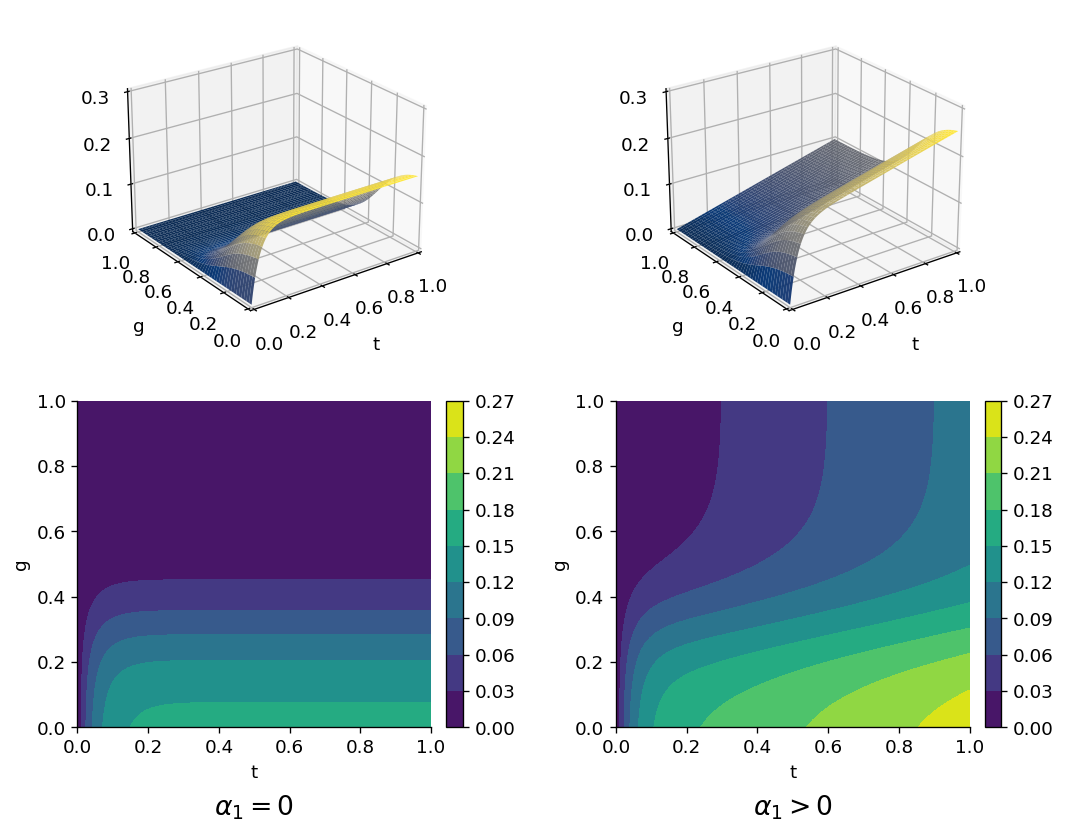

In [58]:
fig = plt.figure(figsize=(9, 7))
surface_vmax = 0.3
for i, case in enumerate(cases):
    params = case["params"]
    Z = model_surface(T, G, **params)
    levels = case["levels"]

    ax3d = fig.add_subplot(2, 2, i + 1, projection="3d")
    ax3d.plot_surface(T, G, Z, cmap="cividis", linewidth=0, antialiased=True, alpha=0.95)
    ax3d.set_xlabel("t", labelpad=8)
    ax3d.set_ylabel("g", labelpad=8)
    ax3d.set_xlim(0, 1)
    ax3d.set_ylim(0, 1)
    ax3d.set_zlim(0, surface_vmax)
    ax3d.view_init(elev=24, azim=-126)

    ax2d = fig.add_subplot(2, 2, i + 3)
    contour = ax2d.contourf(T, G, Z, levels=levels, cmap="viridis", vmin=levels[0], vmax=levels[-1])
    ax2d.set_xlabel("t")
    ax2d.set_ylabel("g")
    ax2d.set_xlim(0, 1)
    ax2d.set_ylim(0, 1)
    ax2d.set_title(case["title"], y=-0.30, fontsize=16)
    fig.colorbar(contour, ax=ax2d, fraction=0.046, pad=0.04)

fig.tight_layout(h_pad=3.0, w_pad=2.0)
fig.savefig("level_curves_survsurf-v2_one_neuron_one_layer.png", bbox_inches="tight")
plt.show()

## Plateau versus vertical divergence

The analytic curve makes the two limiting behaviors explicit after mapping the public surface height $y$ through $C_y=\operatorname{arctanh}(y)$.

When $\alpha=0$, the numerator is fixed at $C_y$. If $m_t>0$, then $\sigma(m_t t+c_t)\to1$ as $t\to\infty$, so the level curve approaches

$$
q_y(\infty)=\frac{c_g-\mathrm{logit}\left(\frac{\operatorname{arctanh}(y)}{\gamma[1-\sigma(c_t)]}\right)}{m_g},
$$

provided the ratio lies between zero and one.

When $\alpha>0$, the numerator $C_y-\alpha t$ shrinks to zero at $t=C_y/\alpha$. Since $\mathrm{logit}(p)\to-\infty$ as $p\downarrow0$, the level curve tends to $+\infty$ as $t\uparrow C_y/\alpha$.

/tmp/ipykernel_23263/1277011691.py:63: RuntimeWarning: divide by zero encountered in divide
  ratio = (raw_y - alpha * t) / denom


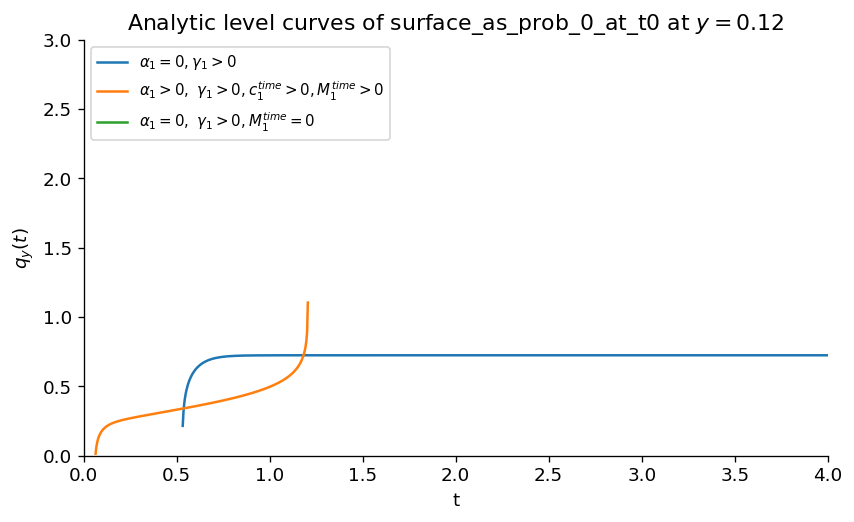

In [5]:
y = 0.12
t_long = np.linspace(1e-4, 4.0, 1000)

fig, ax = plt.subplots(figsize=(8, 4.5))
for case in cases:
    q = level_curve_q_prob(t_long, y, **case["params"])
    visible = (q >= 0) & (q <= 3)
    ax.plot(t_long[visible], q[visible], label=case["title"])

ax.set_xlabel("t")
ax.set_ylabel(r"$q_y(t)$")
ax.set_title(rf"Analytic level curves of surface_as_prob_0_at_t0 at $y={y}$")
ax.set_xlim(0, 4)
ax.set_ylim(0, 3)
ax.legend(loc="upper left", fontsize=9)
plt.show()

## Effect of the time bias $c_t$

The denominator contains $\sigma(m_t t+c_t)-\sigma(c_t)$, whose sigmoid inflection is at $t=-c_t/m_t$. If $c_t\geq0$, that inflection point is outside the positive-time domain and the denominator is already in its saturating phase for $t\geq0$. If $c_t<0$, the positive-time domain includes an early accelerating phase, which can expose stronger curvature changes in $q_y(t)$.

/tmp/ipykernel_23263/1277011691.py:63: RuntimeWarning: divide by zero encountered in divide
  ratio = (raw_y - alpha * t) / denom


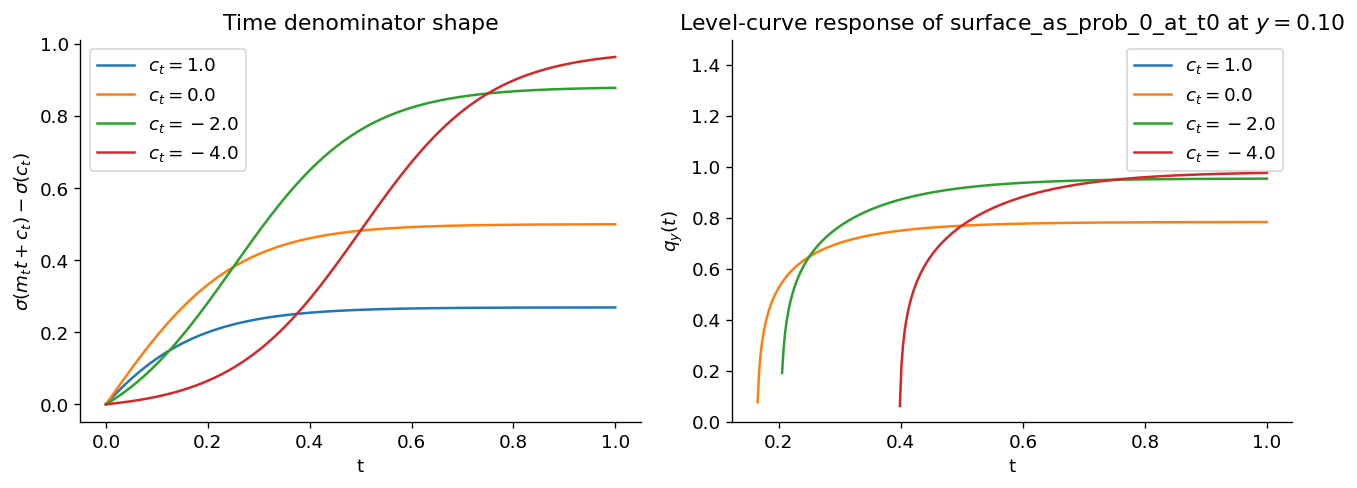

In [6]:
m_time = 8.0
c_values = [1.0, 0.0, -2.0, -4.0]
t_den = np.linspace(0, 1, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for c_time in c_values:
    axes[0].plot(t_den, delta_time(t_den, m_time, c_time), label=rf"$c_t={c_time}$")
    p = dict(alpha=0.0, gamma=0.35, m_time=m_time, c_time=c_time, m_grade=6.0, c_grade=5.0)
    q = level_curve_q_prob(t_den, 0.10, **p)
    in_view = (q >= 0) & (q <= 1.5)
    axes[1].plot(t_den[in_view], q[in_view], label=rf"$c_t={c_time}$")

axes[0].set_xlabel("t")
axes[0].set_ylabel(r"$\sigma(m_t t+c_t)-\sigma(c_t)$")
axes[0].set_title("Time denominator shape")
axes[0].legend()

axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$q_y(t)$")
axes[1].set_title(r"Level-curve response of surface_as_prob_0_at_t0 at $y=0.10$")
axes[1].set_ylim(0, 1.5)
axes[1].legend()

fig.tight_layout()
plt.show()

## Effect of the grade bias $c_g$

The grade bias shifts the solved curve vertically because it appears additively in $c_g-\mathrm{logit}(\cdot)$. Larger $c_g$ exposes higher-grade portions of the same analytic curve in the $t\geq0$, $g>0$ plotting window.

/tmp/ipykernel_23263/1277011691.py:63: RuntimeWarning: divide by zero encountered in divide
  ratio = (raw_y - alpha * t) / denom


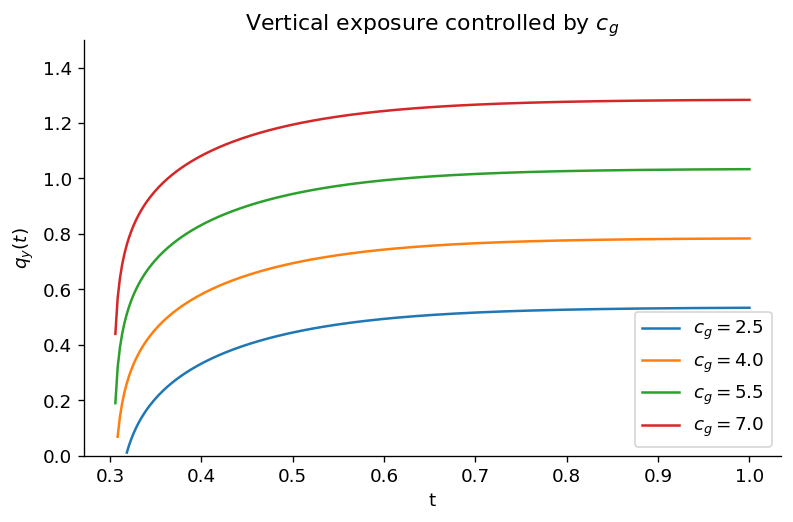

In [7]:
base = dict(alpha=0.0, gamma=0.32, m_time=8.0, c_time=-3.0, m_grade=6.0, c_grade=5.0)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for c_grade in [2.5, 4.0, 5.5, 7.0]:
    p_case = {**base, "c_grade": c_grade}
    q = level_curve_q_prob(t_den, 0.10, **p_case)
    in_view = (q >= 0) & (q <= 1.5)
    ax.plot(t_den[in_view], q[in_view], label=rf"$c_g={c_grade}$")

ax.set_xlabel("t")
ax.set_ylabel(r"$q_y(t)$")
ax.set_title(r"Vertical exposure controlled by $c_g$")
ax.set_ylim(0, 1.5)
ax.legend()
plt.show()